# L0.5 — Derivatives

Hands-on notebook for the lesson [`0-5-derivatives.mdx`](../../llm-quest-theory/level-0/0-5-derivatives.mdx).

> **Learning objectives**
> - Grasp the derivative as the "instantaneous rate of change" and draw tangent lines.
> - Compare numerical derivatives (finite difference) with symbolic derivatives (SymPy).
> - Run gradient descent by hand on `f(x) = x^2 - 4x + 3` to feel the spirit of ML.

## Connection to the theory
Covers **§1–§5** of the `.mdx`. This is the "engine" for everything later: gradient descent (1-2), backprop (3-3), LLM training optimizers (5-3).

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Numerical derivative via finite difference

$$f'(x_0) \approx \frac{f(x_0 + h) - f(x_0 - h)}{2h}$$

(central difference — second-order accurate).

In [2]:
def num_diff(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

tests = [
    ("x^2  -> 2x",      lambda x: x ** 2,          lambda x: 2 * x,          3.0),
    ("sin  -> cos",     np.sin,                    np.cos,                   1.0),
    ("e^x  -> e^x",     np.exp,                    np.exp,                   0.5),
    ("ln   -> 1/x",     np.log,                    lambda x: 1 / x,          2.0),
]
for name, f, df_true, x0 in tests:
    print(f"{name:<18}  num={num_diff(f, x0):.6f}  analytic={df_true(x0):.6f}")

x^2  -> 2x          num=6.000000  analytic=6.000000
sin  -> cos         num=0.540302  analytic=0.540302
e^x  -> e^x         num=1.648721  analytic=1.648721
ln   -> 1/x         num=0.500000  analytic=0.500000


## 2. Tangent line at a point
For `f(x) = x^3 - 3x`, draw the tangent line at three points where the derivative is negative, zero, and positive.

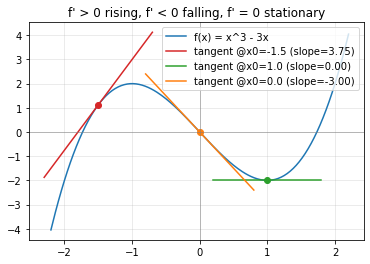

In [3]:
def f(x): return x ** 3 - 3 * x

x = np.linspace(-2.2, 2.2, 200)
fig, ax = plt.subplots()
ax.plot(x, f(x), color="tab:blue", label="f(x) = x^3 - 3x")

for x0, color in [(-1.5, "tab:red"), (1.0, "tab:green"), (0.0, "tab:orange")]:
    slope = num_diff(f, x0)
    xs = np.linspace(x0 - 0.8, x0 + 0.8, 2)
    ax.plot(xs, f(x0) + slope * (xs - x0), color=color,
            label=f"tangent @x0={x0} (slope={slope:.2f})")
    ax.plot(x0, f(x0), "o", color=color)

ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.grid(alpha=0.3); ax.legend(); ax.set_title("f' > 0 rising, f' < 0 falling, f' = 0 stationary")
plt.show()

## 3. Symbolic derivative with SymPy (optional)
SymPy returns derivatives as formulas, handy for cross-checking.

> If not installed: `pip install sympy`. The package is already in `requirements.txt`.

In [4]:
try:
    import sympy as sp
    x_sym = sp.symbols("x")
    expr = x_sym ** 2 - 4 * x_sym + 3
    d_expr = sp.diff(expr, x_sym)
    print("f(x)  =", expr)
    print("f'(x) =", d_expr)
    print("stationary: f'(x) = 0 at x =", sp.solve(d_expr, x_sym))
except ImportError:
    print("SymPy is not installed — skipping the symbolic cross-check.")

f(x)  = x**2 - 4*x + 3
f'(x) = 2*x - 4
stationary: f'(x) = 0 at x = [2]


## 4. Hand-run gradient descent on `f(x) = x^2 - 4x + 3`
Use the closed-form derivative `f'(x) = 2x - 4` from §5 of the theory directly.

In [5]:
def g(x): return x ** 2 - 4 * x + 3
def g_grad(x): return 2 * x - 4

x_t = 0.0
lr = 0.1
history = [x_t]
for step in range(60):
    x_t = x_t - lr * g_grad(x_t)
    history.append(x_t)

print(f"Converged to x = {x_t:.4f} (exact: 2.0)")
print(f"f(x_final) = {g(x_t):.4f} (exact: -1.0)")

Converged to x = 2.0000 (exact: 2.0)
f(x_final) = -1.0000 (exact: -1.0)


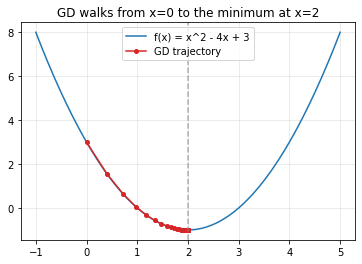

In [6]:
xs = np.linspace(-1, 5, 200)
fig, ax = plt.subplots()
ax.plot(xs, g(xs), color="tab:blue", label="f(x) = x^2 - 4x + 3")
ax.plot(history, [g(h) for h in history], "o-", color="tab:red",
        markersize=4, label="GD trajectory")
ax.axvline(2.0, linestyle="--", color="gray", alpha=0.6)
ax.grid(alpha=0.3); ax.legend(); ax.set_title("GD walks from x=0 to the minimum at x=2")
plt.show()

## 5. Chain rule — a preview of backprop
Let `L(w) = (sin(w^2) - 0.5)^2`. Compute `dL/dw` via the chain rule and compare against finite difference.

In [7]:
def L(w):      return (np.sin(w ** 2) - 0.5) ** 2
def dL(w):
    # chain rule: dL/dw = 2*(sin(w^2)-0.5) * cos(w^2) * 2w
    return 2 * (np.sin(w ** 2) - 0.5) * np.cos(w ** 2) * 2 * w

for w0 in [0.3, 1.0, 1.7]:
    print(f"w={w0}  chain_rule={dL(w0):+.5f}  finite_diff={num_diff(L, w0):+.5f}")

w=0.3  chain_rule=-0.49015  finite_diff=-0.49015
w=1.0  chain_rule=+0.73799  finite_diff=+0.73799
w=1.7  chain_rule=+1.65342  finite_diff=+1.65342


## Quick checks

In [8]:
assert abs(num_diff(np.sin, 1.0) - np.cos(1.0)) < 1e-6
assert abs(history[-1] - 2.0) < 1e-2,   "GD should converge near x=2"
assert abs(g(history[-1]) - (-1.0)) < 1e-2
print("OK — next up: Boss 0-6.")

OK — next up: Boss 0-6.


## Reflection questions

1. If we pick `lr = 1.0` in section 4, what happens? Try it.
2. Why is the central difference more accurate than the forward difference `(f(x+h)-f(x))/h`?
3. How is the chain rule used in a 2-layer neural network? (Preview for lesson 3-3.)

## References
- Source theory: [`0-5-derivatives.mdx`](../../llm-quest-theory/level-0/0-5-derivatives.mdx)
- Next: [`0-6-house-price-boss`](0-6-house-price-boss.ipynb) — the Level 0 boss.